In [34]:
import matplotlib.pyplot as plt
import numpy as np

# image data
a = np.array([0.313660827978, 0.365348418405, 0.423733120134,
              0.365348418405, 0.439599930621, 0.525083754405,
              0.423733120134, 0.525083754405, 0.651536351379]).reshape(3,3)

"""
for the value of "interpolation", check this:
http://matplotlib.org/examples/images_contours_and_fields/interpolation_methods.html
for the value of "origin"= ['upper', 'lower'], check this:
http://matplotlib.org/examples/pylab_examples/image_origin.html
"""
plt.imshow(a,interpolation='nearest',cmap='bone',origin='upper')
# 'nearest' → 马赛克效果，适合热力图、像素图（每个格子边界清晰）
# 'bilinear' → 平滑模糊，适合照片
# 'bicubic' → 更平滑
#upper正序，lower逆序
plt.colorbar(shrink=0.9)
#右边预览条shrink=0.9压缩百分之九十

plt.xticks(())
plt.yticks(())
plt.show()

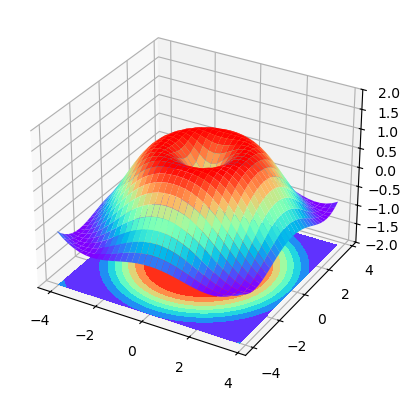

In [36]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
 #如果变成单独窗口qt则可以移动
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
# X, Y value
X = np.arange(-4, 4, 0.25)
Y = np.arange(-4, 4, 0.25)
X, Y = np.meshgrid(X, Y)
R = np.sqrt(X ** 2 + Y ** 2)
# height value
Z = np.sin(R)

ax.plot_surface(X, Y, Z, rstride=1, cstride=1, cmap='rainbow')
#column stride 网格长宽，组成小格子的大小
"""
============= ================================================
        Argument      Description
        ============= ================================================
        *X*, *Y*, *Z* Data values as 2D arrays
        *rstride*     Array row stride (step size), defaults to 10
        *cstride*     Array column stride (step size), defaults to 10
        *color*       Color of the surface patches
        *cmap*        A colormap for the surface patches.
        *facecolors*  Face colors for the individual patches
        *norm*        An instance of Normalize to map values to colors
        *vmin*        Minimum value to map
        *vmax*        Maximum value to map
        *shade*       Whether to shade the facecolors
        ============= ================================================
"""

# I think this is different from plt12_contours
ax.contourf(X, Y, Z, zdir='z', offset=-2, cmap=plt.get_cmap('rainbow'))
# zdir='z'	水平切	🔪 拦腰平切一刀	从上面俯视，看到包子俯视图的彩色圈圈
# zdir='x'	竖着切（正面对半）	🔪 从额头到下巴竖切	从侧面看，看到包子侧面的轮廓线
# `zdir='y'	竖着切（侧面剖）	🔪 从左耳到右耳竖切	从另一个侧面看，看到另一面的轮廓
"""
==========  ================================================
        Argument    Description
        ==========  ================================================
        *X*, *Y*,   Data values as numpy.arrays
        *Z*
        *zdir*      The direction to use: x, y or z (default)
        *offset*    If specified plot a projection of the filled contour
                    on this position in plane normal to zdir
        ==========  ================================================
"""

ax.set_zlim(-2, 2)


plt.show()

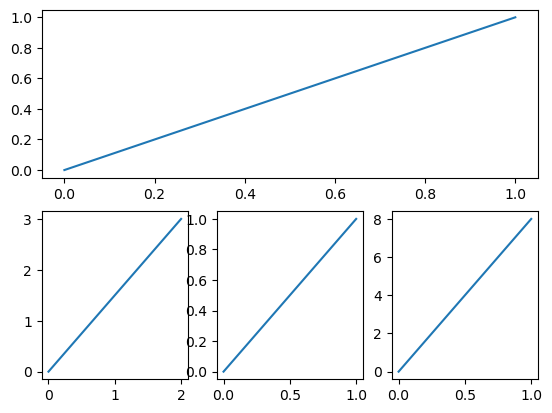

In [ ]:
#subplot 多个显示
plt.figure()

plt.subplot(2,1,1)#第一行占一个
plt.plot([0,1],[0,1])

plt.subplot(2,3,4)#第二行重新分，并且默认第一行已经占了三个
plt.plot([0,2],[0,3])

plt.subplot(2,3,5)
plt.plot([0,1],[0,1])

plt.subplot(2,3,6)
plt.plot([0,1],[0,8])


plt.show()

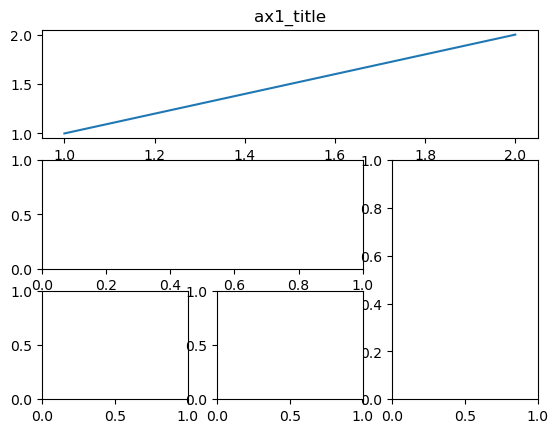

In [62]:
#subplot 分格显示
import matplotlib.gridspec as gridspec

#方法一：subplot2grid
plt.Figure()
ax1=plt.subplot2grid((3,3),(0,0),colspan=3,rowspan=1)
ax1.plot([1,2],[1,2])
ax1.set_title('ax1_title')#和之前不一样，需要加set，因为对象不同
ax2=plt.subplot2grid((3,3),(1,0),colspan=2,rowspan=1)
ax3=plt.subplot2grid((3,3),(1,2),colspan=2,rowspan=2)
ax4=plt.subplot2grid((3,3),(2,0),colspan=1,rowspan=1)
ax5=plt.subplot2grid((3,3),(2,1),colspan=1,rowspan=1)

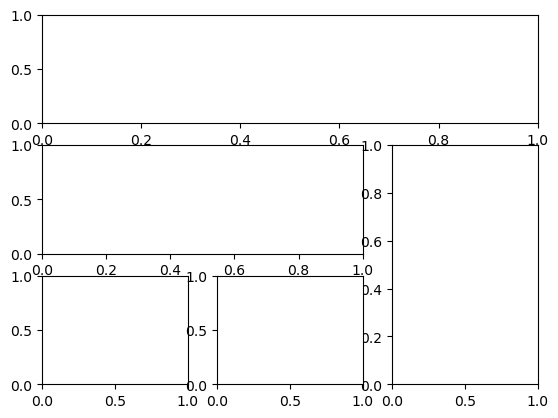

In [ ]:
#方法2：gridspec
plt.Figure()
gs=gridspec.GridSpec(3,3)
ax1=plt.subplot(gs[0,:])
ax2=plt.subplot(gs[1,:2])
ax3=plt.subplot(gs[1:,2])
ax4=plt.subplot(gs[-1,0])
ax5=plt.subplot(gs[-1,-2])
#gs[行，列]
plt.show()


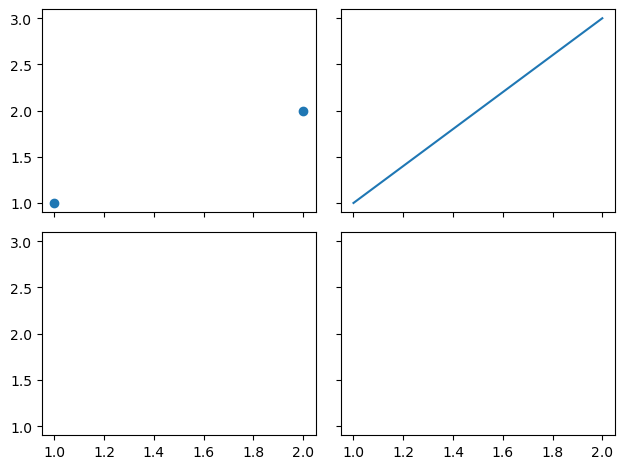

In [70]:
#方法3
f, ((ax11, ax12), (ax13, ax14)) = plt.subplots(2, 2, sharex=True, sharey=True)
#（（第一行所有窗口）（第二行所有））
#sharex共享X轴
ax11.scatter([1,2], [1,2])
ax12.plot([1,2],[1,3])
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'title inside 2')

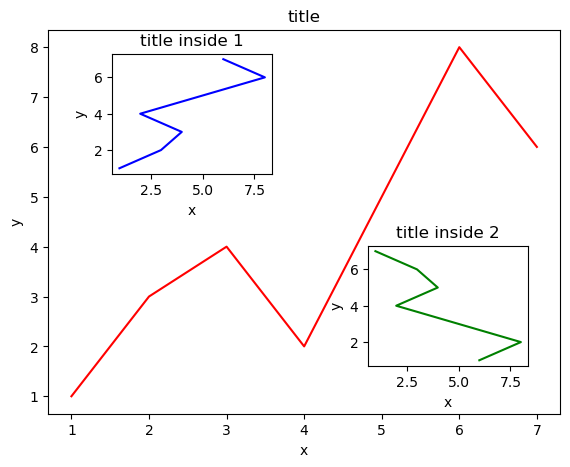

In [ ]:
#plot in plot 图中图

fig = plt.figure()
x = [1, 2, 3, 4, 5, 6, 7]
y = [1, 3, 4, 2, 5, 8, 6]

# below are all percentage
left, bottom, width, height = 0.1, 0.1, 0.8, 0.8 #坐标的长宽
ax1 = fig.add_axes([left, bottom, width, height])  # main axes
ax1.plot(x, y, 'r')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('title')

ax2 = fig.add_axes([0.2, 0.6, 0.25, 0.25])  # inside axes
# left=0.2	离左边 20% 的位置	从左边框到子图左边框
# bottom=0.6	离底部 60% 的位置	从下边框到子图下边框
# width=0.25	宽度占整图的 25%	子图多宽
# height=0.25	高度占整图的 25%	子图多高
ax2.plot(y, x, 'b')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('title inside 1')

plt.axes([.6,.2,0.25,0.25])
plt.plot(y[::-1],x,'g')
#y[::-1]     # 反转整个数组
#y[::1]      # 原样（步长1）
plt.xlabel('x')
plt.ylabel('y')
plt.title('title inside 2')



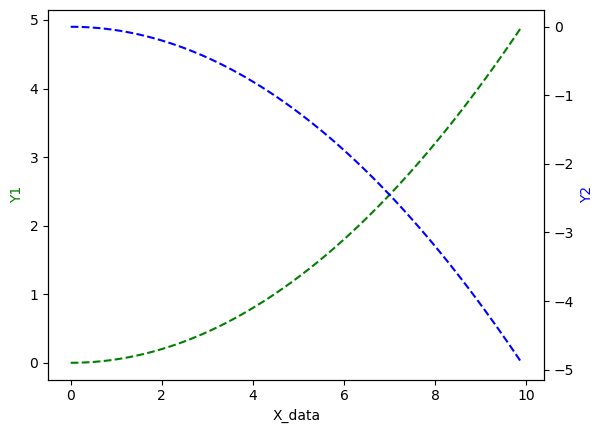

In [4]:
#次坐标轴
import matplotlib.pyplot as plt
import numpy as np

x=np.arange(0,10,0.1)
y1=0.05*x**2
y2=-1*y1

fig,ax1=plt.subplots()
ax2=ax1.twinx()#twinx共享X轴，twiny
# ax1.twinx()	X 轴（底部）	Y 轴（左右各一个）
# ax1.twiny()	Y 轴（左侧）	X 轴（上下各一个）
ax1.plot(x,y1,'g--')
ax2.plot(x,y2,'b--')

ax1.set_xlabel('X_data')
ax1.set_ylabel('Y1',c='g')
ax2.set_ylabel('Y2',c='b')

plt.show()


In [ ]:
#动画
%matplotlib qt
from matplotlib  import pyplot as plt
from matplotlib import animation

fig,ax=plt.subplots()

#生成 x 轴数据：
# 0 到 2π（约 6.28），每隔 0.01 一个点，一共 628 个点。
x=np.arange(0,2*np.pi,0.01)

#画一条 y = sin(x) 的正弦曲线，并把这条线对象存到 line 中。
line,=ax.plot(x,np.sin(x))

# i	帧编号，从 0 到 99（由下面 frames=100 决定）
# x + i/100	每次向右平移一点：i=0 时平移 0，i=50 时平移 0.5，i=99 时平移 0.99
# np.sin(x + i/100)	重新计算平移后的 sin 值
# line.set_ydata(...)	更新线的 y 数据（不改 x 轴，只上下移动波形）
# return line,	告诉 blit 哪些对象更新了
def animation1(i):
    line.set_ydata(np.sin(x+i/100))
    return line,

def init():
     line.set_ydata(np.sin(x))
     return line,


ani=animation.FuncAnimation(fig=fig,func=animation1,frames=100,
                            init_func=init,interval=20,blit=True)
# ani = animation.FuncAnimation(
#     fig=fig,          # 在哪张图上播放
#     func=animation1,   # 每帧执行的函数
#     frames=100,        # 一共 100 帧（i 从 0 到 99）
#     init_func=init,    # 初始帧函数
#     interval=20,       # 每帧间隔 20 毫秒（约 50 帧/秒）
#     blit=True          # 只重画变化的元素，提高性能
# )



plt.show()

